In [ ]:
system("apt-get update", intern = TRUE)
system("apt-get install -y libmagick++-dev imagemagick", intern = TRUE)
install.packages("magick", repos = "https://cloud.r-project.org")

[1] "Get:1 https://cli.github.com/packages stable InRelease [3,917 B]"                            
 [2] "Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]"        
 [3] "Get:3 https://cli.github.com/packages stable/main amd64 Packages [354 B]"                    
 [4] "Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]"                        
 [5] "Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease"                                      
 [6] "Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,946 kB]"             
 [7] "Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]"                   
 [8] "Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]"                     
 [9] "Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease"                
[10] "Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,931 kB]"              
[11] "Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease"                
[12] "Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]"                  
[13] "Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,011 kB]"  
[14] "Get:14 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,842 kB]"      
[15] "Get:15 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,618 kB]"    
[16] "Get:16 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]"        
[17] "Get:17 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]"  
[18] "Get:18 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]"
[19] "Fetched 38.0 MB in 4s (10.2 MB/s)"                                                           
[20] "Reading package lists..."

[1] "Reading package lists..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
  [2] "Building dependency tree..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   
  [3] "Reading state information..."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  
  [4] "The following additional packages will be installed:"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
  [5] "  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           
  [6] "  gir1.2-rsvg-2.0 gsfonts imagemagick-6-common imagemagick-6.q16"                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
  [7] "  libdjvulibre-dev libdjvulibre-text libdjvulibre21 libexif-dev libexif-doc"                                     

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(magick)

img <- image_read("p5_image.gif")
img_gray <- image_convert(img, colorspace = "gray")
img_data <- image_data(img_gray, channels = "gray")

A_char <- drop(img_data)
A <- apply(A_char, c(1,2), function(x) as.numeric(x))

dim(A)
range(A)

A <- A/255
range(A)

[1] 1170 1600

[1]   0 255

[1] 0 1

[1] 1170 1600

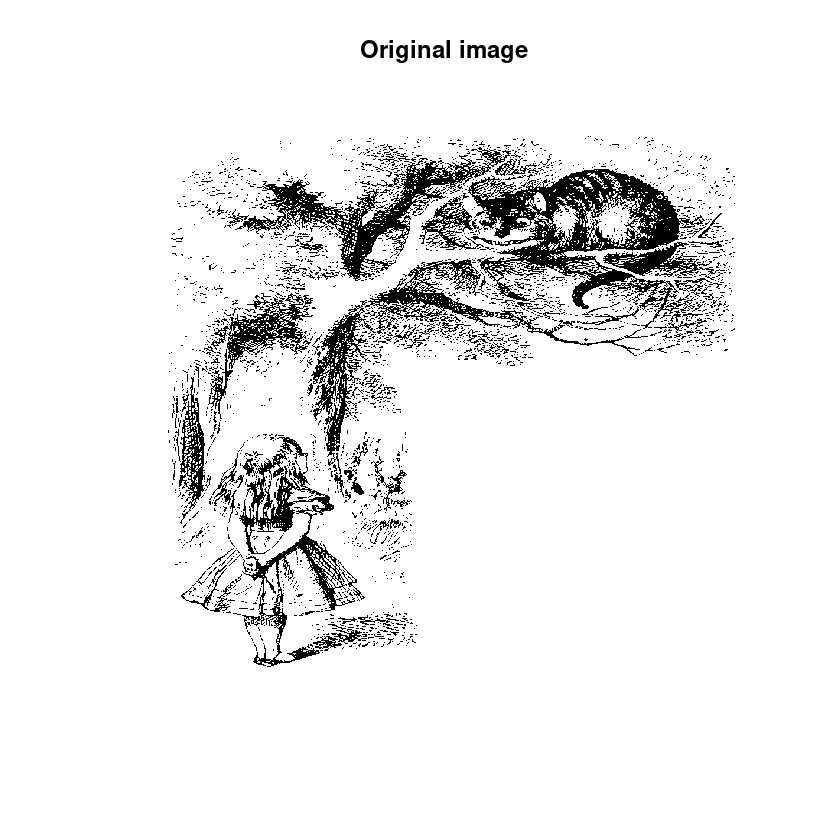

In [ ]:
image(
  A[, ncol(A):1],
  col = gray(seq(0, 1, length.out = 256)),
  axes = FALSE,
  main = "Original image",
  useRaster = TRUE

)
dim(A)

In [ ]:
svd_out <- svd(A)

U <- svd_out$u
D <- svd_out$d
V <- svd_out$v

length(D)
dim(U)
dim(V)
head(D, 10)

reconstruct_k <- function(U, D, V, k) {
  U_k <- U[, 1:k]
  D_k <- diag(D[1:k], nrow = k, ncol = k)
  V_k <- V[, 1:k]
  A_k <- U_k %*% D_k %*% t(V_k)
  return(A_k)
}



[1] 1170

[1] 1170 1170

[1] 1600 1170

[1] 1218.96347  149.44234   90.30990   85.73413   68.03064   63.69150
 [7]   62.04462   56.93041   48.38910   45.33210

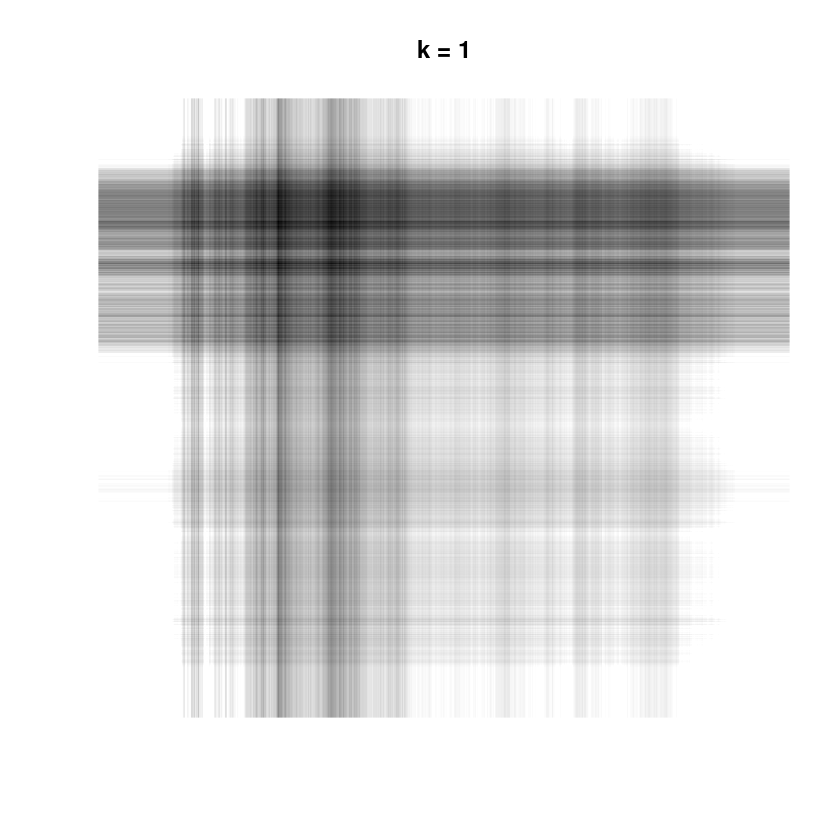

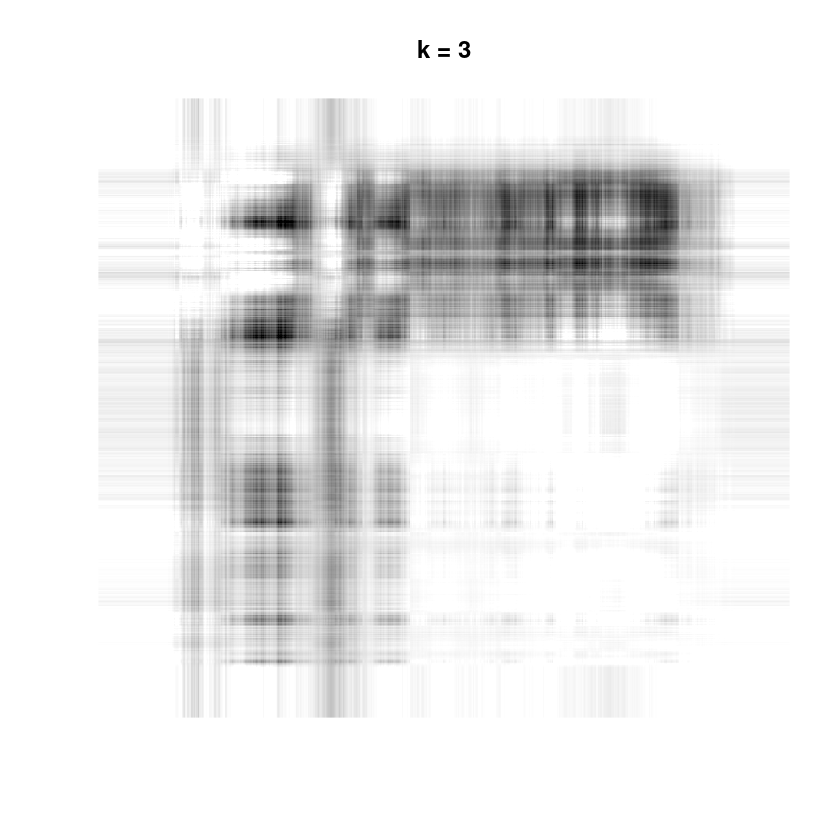

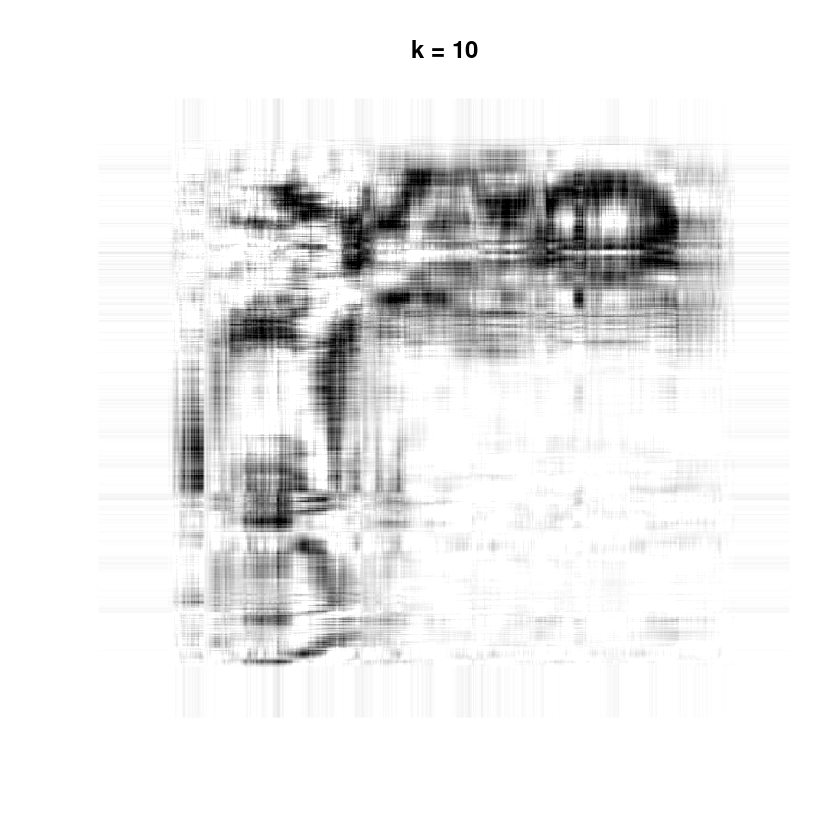

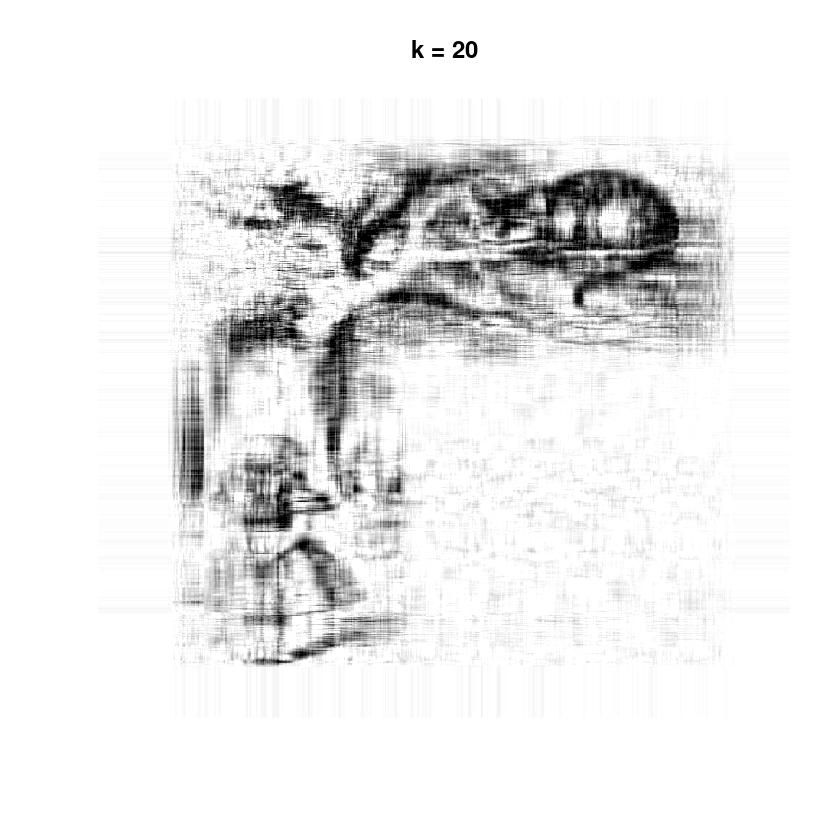

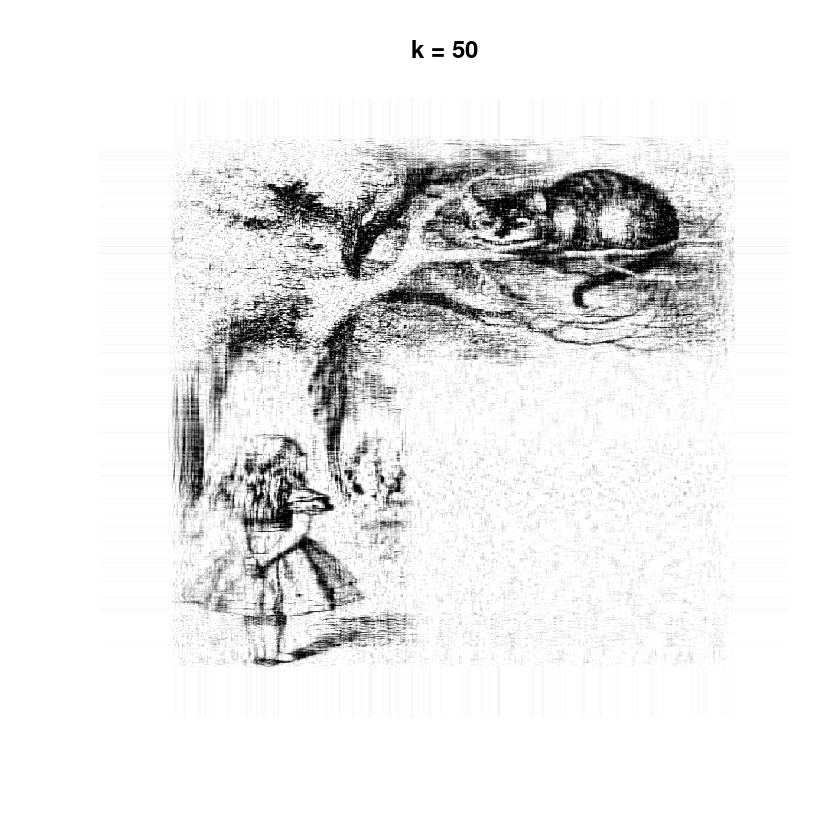

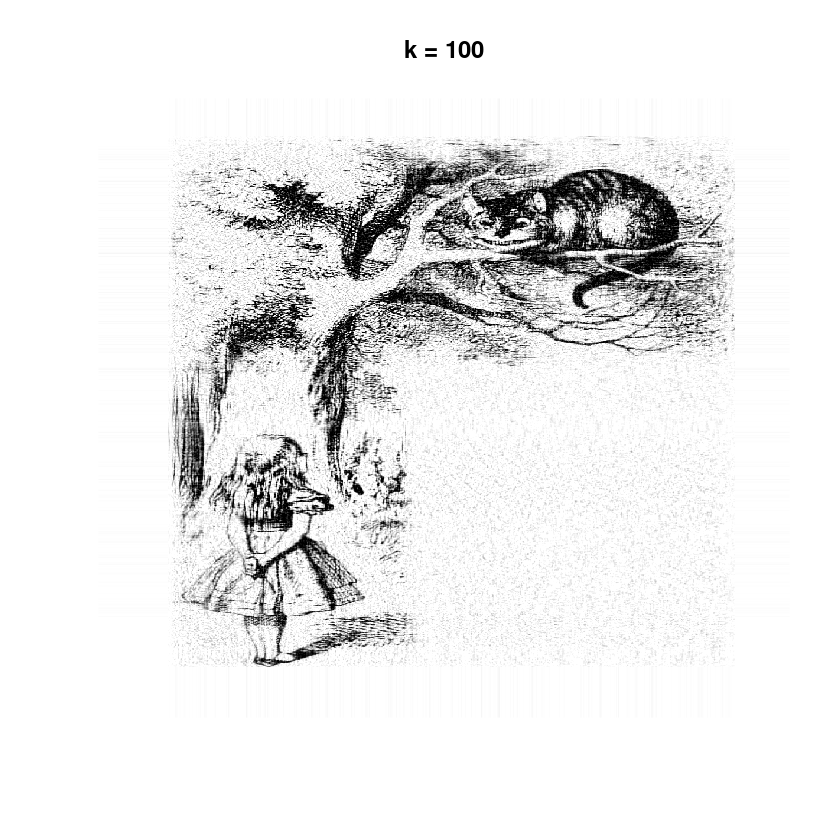

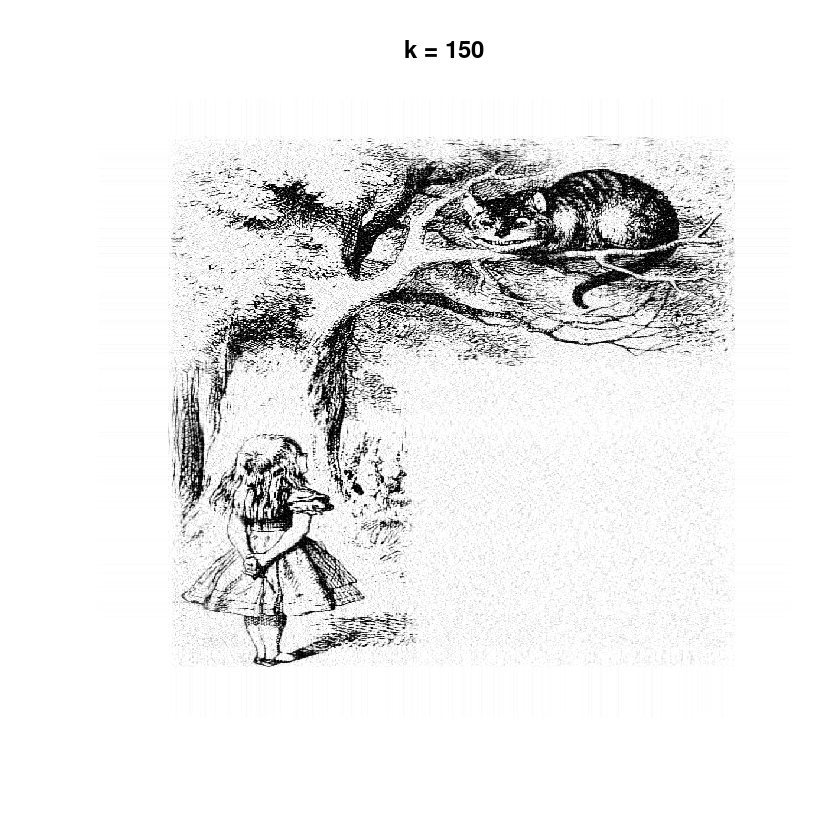

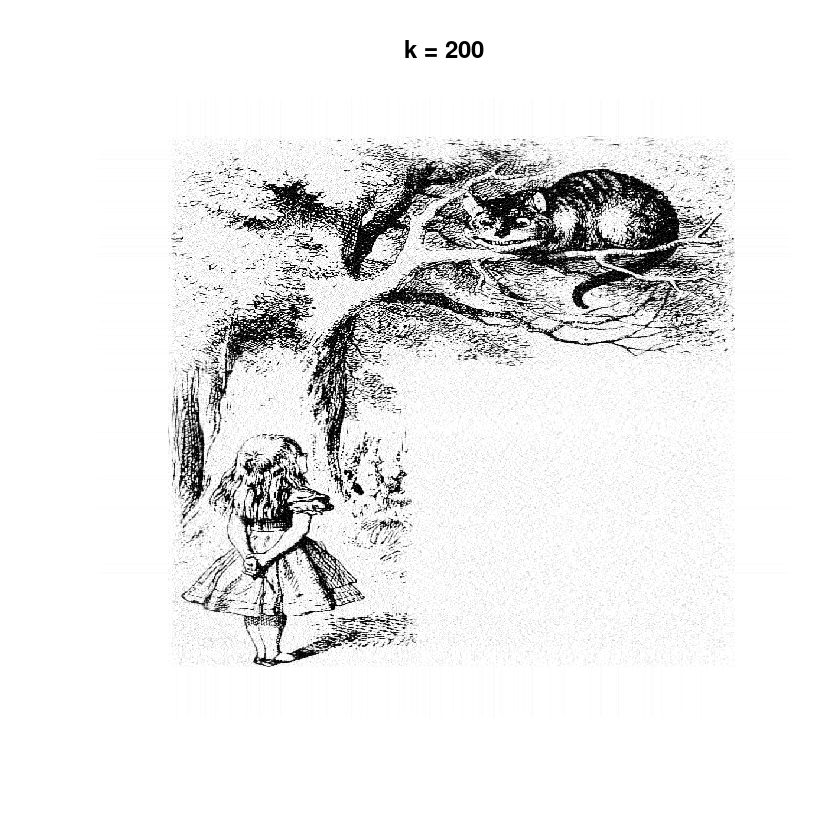

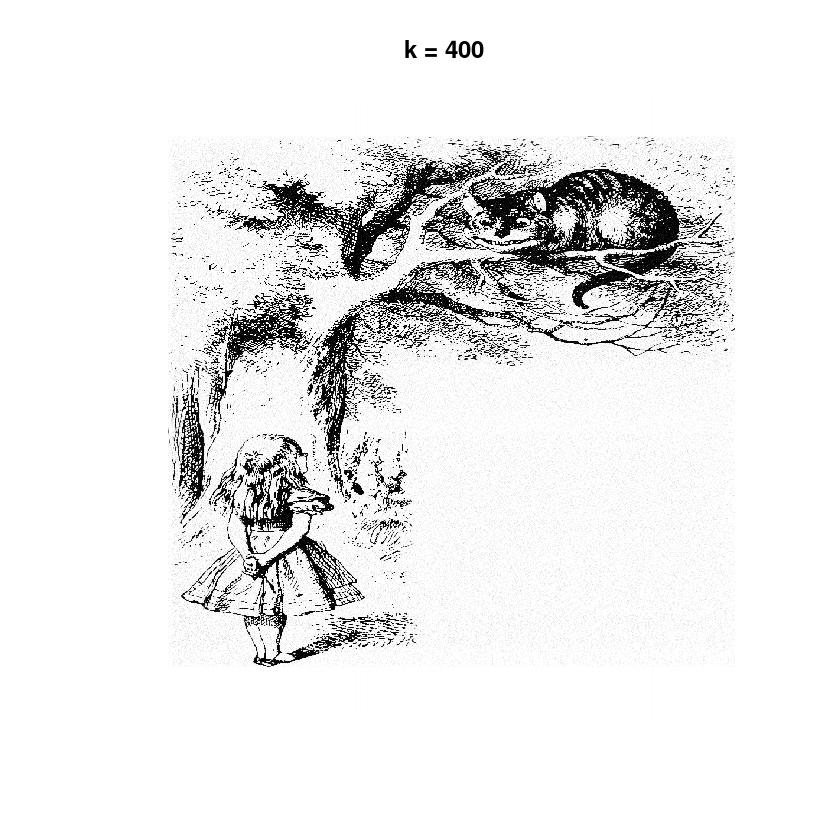

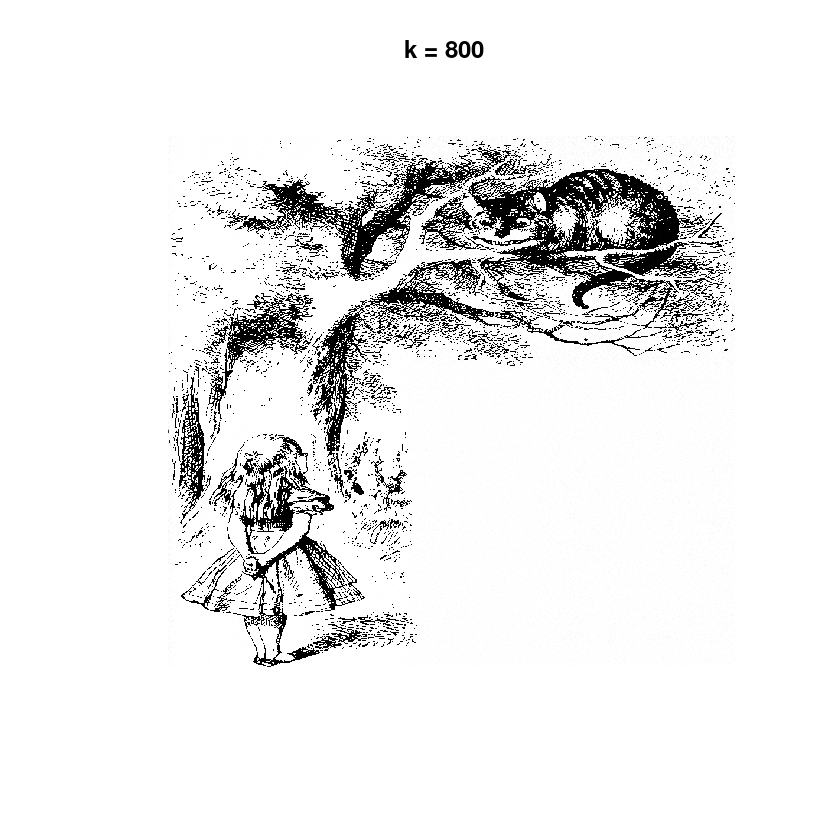

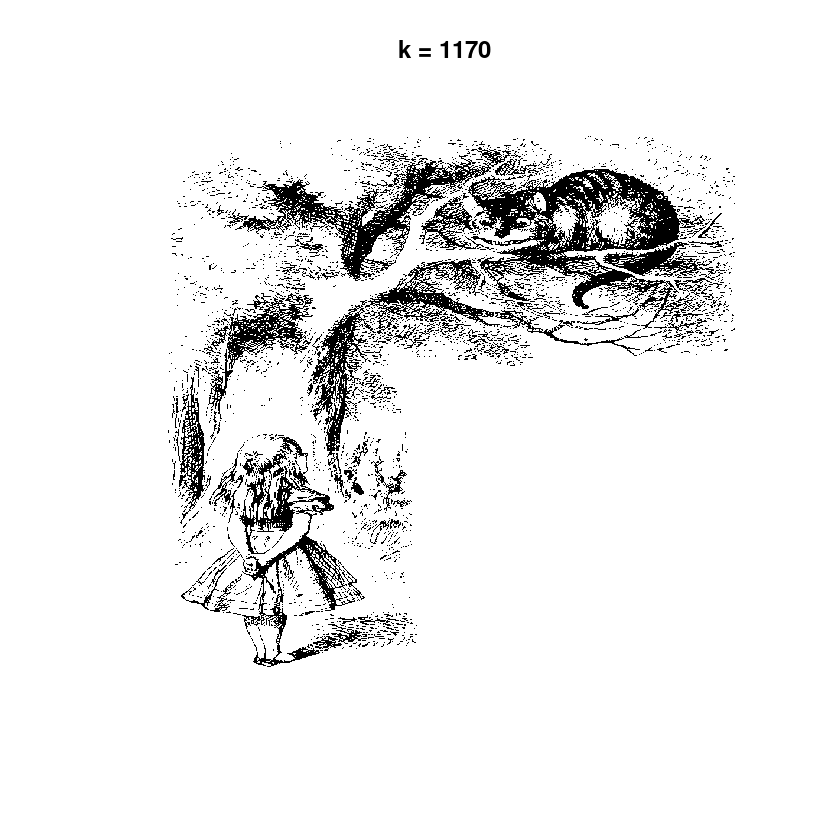

In [ ]:
# k values required in the assignment
k_list <- c(1, 3, 10, 20, 50, 100, 150, 200, 400, 800, 1170)

# store all approximations in a list
A_k_list <- vector("list", length(k_list))
names(A_k_list) <- paste0("k_", k_list)

for (i in seq_along(k_list)) {
  k <- k_list[i]
  A_k_list[[i]] <- reconstruct_k(U, D, V, k)
}

# clip to [0,1]
clip_01 <- function(M) {
  pmin(pmax(M, 0), 1)
}

# picture
for (i in seq_along(k_list)) {
  k <- k_list[i]
  A_k_clip <- clip_01(A_k_list[[i]])

  image(
    A_k_clip[, ncol(A_k_clip):1],
    col = gray(seq(0, 1, length.out = 256)),
    axes = FALSE,
    main = paste("k =", k),
    useRaster = TRUE
  )
}

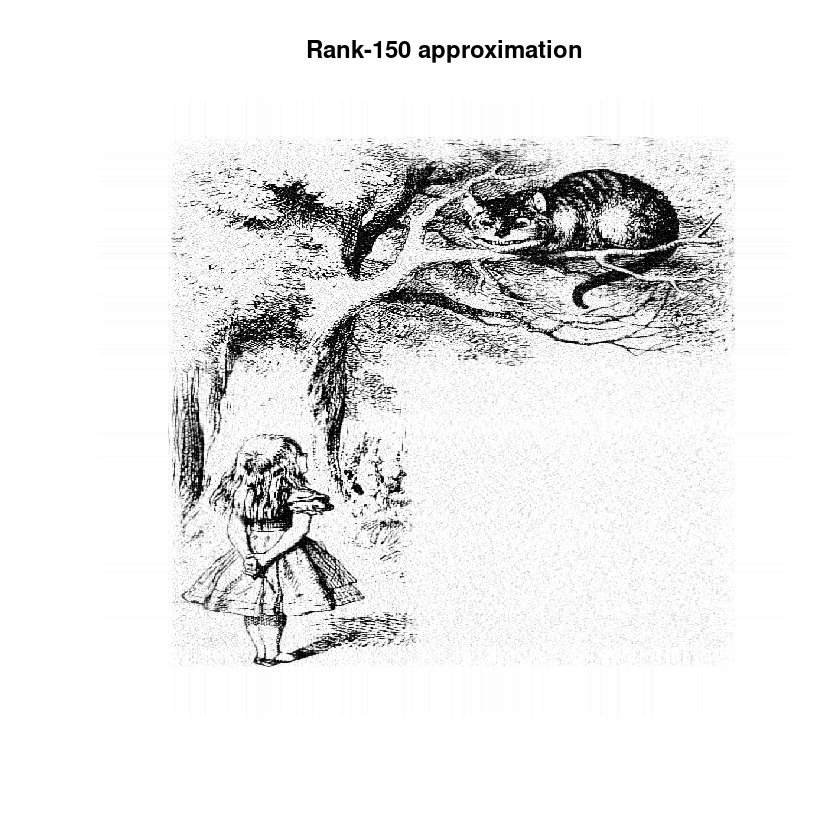

In [ ]:
# A_150_clip <- pmin(pmax(A_150, 0), 1)

# image(
#   x = 1:nrow(A_150_clip),
#   y = 1:ncol(A_150_clip),
#   z = A_150_clip[, ncol(A_150_clip):1],
#   col = gray(seq(0, 1, length.out = 256)),
#   axes = FALSE,
#   xlab = "",
#   ylab = "",
#   main = "Rank-150 approximation",
#   useRaster = TRUE
# )